# Notebook 05 – XGBoost Machine Learning Model

This notebook trains an XGBoost classifier to predict gentrification pressure levels for Copenhagen neighborhoods.

**Key differences from OLD_05:**
- Target variable: `combined_class_idx` from `classified_combined.gpkg` (0=Low/gentrified, 1=Medium, 2=High)
- Input: GT_V3 only (trend + start/end values + volatility features)
- Future predictions for 2025, 2030, 2035 by linearly extrapolating `_end_value` features using `_reg_2015_2020` slopes

**Note on `first_low_period`:** This temporal field is computed and shown for analysis, but is **excluded from model training** to avoid label leakage (it is non-null only for class-0 clusters, which would perfectly reveal the target).

Predictions are saved in `results/models/`.

## 1. Imports & Configuration

In [1]:
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import (
    accuracy_score, classification_report,
    precision_score, recall_score, f1_score,
    ConfusionMatrixDisplay
)
from sklearn.utils.class_weight import compute_class_weight

In [2]:
# ── Configuration ────────────────────────────────────────────────────────────

# Paths
FEATURES_PATH       = "../data/raw/GT_V4_data.csv"
#COMBINED_GPK_PATH   = "../data/processed/classified_gt/classified_combined_consec2.gpkg"
#COMBINED_GPK_PATH   = "../data/processed/classified_gt/classified_combined.gpkg"7-# change between different classified combined gpkg versions
COMBINED_GPK_PATH   = "../data/processed/classified_gt/classified_combined.gpkg" # change between different classified combined gpkg versions
RESULTS_DIR         = "../results/models"

# The 6 historical periods (in order)
PERIODS = ['1990_1995', '1995_2000', '2000_2005', '2005_2010', '2010_2015', '2015_2020']

# Base feature names (19 socio-economic indicators)
BASE_FEATURES = [
    'EMUB', 'PMB', 'PUB', 'age_18_25', 'age_26_40', 'age_41_55', 'age_56_69',
    'crime_main_y', 'disp_inc', 'emp', 'grund', 'gym_erhv', 'lvu',
    'mean_sqm', 'mig_in', 'mig_out', 'ool', 'public_housing', 'unemp'
]

# Future horizons: {year: years_ahead_from_2020}
FUTURE_HORIZONS = {2025: 5, 2030: 10, 2035: 15}

# Ordinal mapping for first_low_period
PERIOD_ORDINAL = {p: i+1 for i, p in enumerate(PERIODS)}  # 1990_1995→1 … 2015_2020→6

os.makedirs(RESULTS_DIR, exist_ok=True)
print("Configuration loaded.")
print("Period ordinal map:", PERIOD_ORDINAL)


Configuration loaded.
Period ordinal map: {'1990_1995': 1, '1995_2000': 2, '2000_2005': 3, '2005_2010': 4, '2010_2015': 5, '2015_2020': 6}


## 2. Load Data

In [3]:
def _ensure_cluster_id(df):
    """Normalize join key to 'cluster_id' regardless of original column name."""
    if 'cluster_id' in df.columns:
        return df
    matches = [c for c in df.columns if c.lower() == 'cluster_id']
    if matches:
        return df.rename(columns={matches[0]: 'cluster_id'})
    heur = [c for c in df.columns if ('cluster' in c.lower()) or ('munic' in c.lower())]
    if heur:
        print(f"INFO: Using '{heur[0]}' as 'cluster_id'")
        return df.rename(columns={heur[0]: 'cluster_id'})
    raise KeyError("No join key found. Expected 'cluster_id' or a column containing 'cluster'/'munic'.")

In [ ]:
# Load GT_V4 features
data = pd.read_csv(FEATURES_PATH)
data = _ensure_cluster_id(data)
print(f"GT_V2 features loaded: {data.shape}")
data.head()

GT_V2 features loaded: (13519, 161)


,cluster_id,EMUB_reg_1990_2000,EMUB_reg_2000_2010,EMUB_reg_2010_2020,EMUB_start_value,EMUB_end_value,EMUB_std_1990_2000,EMUB_std_2000_2010,EMUB_std_2010_2020,PMB_reg_1990_2000,...,public_housing_std_2000_2010,public_housing_std_2010_2020,unemp_reg_1990_2000,unemp_reg_2000_2010,unemp_reg_2010_2020,unemp_start_value,unemp_end_value,unemp_std_1990_2000,unemp_std_2000_2010,unemp_std_2010_2020
0,101_1,-9.350334,-18.151373,-1.145663,16.47,12.08,2.906609,1.975779,2.237938,1.825004,...,0.020538,0.031334,-28.686327,19.172932,20.820189,3.73,3.83,0.987198,0.787551,0.840009
1,101_10,2.666391,1.308637,-14.825119,48.38,42.86,1.612371,1.988609,3.425315,22.507553,...,0.000000,0.000000,-45.742574,142.335766,-18.524096,5.05,5.41,2.109916,1.552912,1.366033
2,101_100,5.334988,2.120141,7.925523,56.42,65.50,4.836758,1.896757,2.030350,-12.530120,...,0.000000,0.000000,-47.854785,-26.793249,-20.172911,18.18,5.54,5.985839,2.164736,1.017834
3,101_1000,17.634063,6.214786,-19.627070,49.79,50.00,3.216952,2.667329,6.110488,172.457627,...,0.000000,0.000000,36.416185,-18.785311,12.000000,5.19,6.44,2.397558,1.557712,1.553534
4,101_1001,-7.077768,3.976357,-1.937984,80.11,75.90,1.871905,1.390989,1.838295,15.042373,...,0.043921,0.012863,-78.205128,113.235294,-52.413793,6.24,1.38,1.986753,0.712467,0.574383


In [5]:
# Load combined classification GeoPackage (target + first_low_period)
gdf_combined = gpd.read_file(COMBINED_GPK_PATH)
gdf_combined = _ensure_cluster_id(gdf_combined)

# Normalize the temporal column to 'first_low_period' regardless of source file
# (classified_combined uses 'first_low_period'; consec variants use 'first_consec_low_period')
if 'first_consec_low_period' in gdf_combined.columns and 'first_low_period' not in gdf_combined.columns:
    gdf_combined = gdf_combined.rename(columns={'first_consec_low_period': 'first_low_period'})

# Align cluster_id dtype to string (strip leading zeros / whitespace)
gdf_combined['cluster_id'] = gdf_combined['cluster_id'].astype(str).str.strip().str.lstrip('0')
data['cluster_id'] = data['cluster_id'].astype(str).str.strip().str.lstrip('0')

print(f"classified_combined loaded: {gdf_combined.shape}")
print("Columns:", list(gdf_combined.columns))
gdf_combined[['cluster_id', 'combined_class_idx', 'combined_class', 'first_low_period']].head()


classified_combined loaded: (2232, 9)
Columns: ['area', 'cluster_id', 'id_munic', 'munic_code', 'avg_mean', 'combined_class_idx', 'combined_class', 'first_low_period', 'geometry']


,cluster_id,combined_class_idx,combined_class,first_low_period
0,101_1,0,Low,2010_2020
1,101_2,1,Medium,None
2,101_3,0,Low,2010_2020
3,101_4,1,Medium,None
4,101_5,0,Low,2010_2020


In [6]:
# Keep only the columns we need from the GeoPackage
labels = gdf_combined[['cluster_id', 'combined_class_idx', 'combined_class', 'first_low_period']].copy()
labels = labels.drop_duplicates('cluster_id')

# Merge into feature data
n_before = len(data)
data = data.merge(labels, on='cluster_id', how='left')
missing_target = data['combined_class_idx'].isna().sum()
print(f"Merged: {len(data)} rows (was {n_before}). Missing target values: {missing_target}")

data[['cluster_id', 'combined_class_idx', 'combined_class', 'first_low_period']].head(10)

Merged: 13519 rows (was 13519). Missing target values: 11287


,cluster_id,combined_class_idx,combined_class,first_low_period
0,101_1,0.0,Low,2010_2020
1,101_10,0.0,Low,2010_2020
2,101_100,2.0,High,None
3,101_1000,0.0,Low,1990_2000
4,101_1001,2.0,High,None
5,101_1002,0.0,Low,1990_2000
6,101_1003,2.0,High,None
7,101_1004,0.0,Low,2000_2010
8,101_1005,2.0,High,None
9,101_1006,2.0,High,None


## 3. Temporality Feature Engineering

`first_low_period` records the earliest period a cluster was classified Low (gentrified). It is encoded as an ordinal integer (1–6) for inspection:
- `'1990_1995'` → 1, `'1995_2000'` → 2, ..., `'2015_2020'` → 6
- `None` / NaN (never classified Low) → 0

> **Important:** `first_low_period_encoded` is added to `data` for analysis purposes only.  
> It is **not included in the training feature matrix X** because it is non-zero exclusively for class-0 clusters, which constitutes label leakage and produces artificially perfect class-0 metrics.

In [7]:
data['first_low_period_encoded'] = (
    data['first_low_period']
    .map(PERIOD_ORDINAL)
    .fillna(0)
    .astype(int)
)

print("first_low_period_encoded distribution:")
print(data.groupby('combined_class_idx')['first_low_period_encoded'].value_counts().sort_index())

first_low_period_encoded distribution:
combined_class_idx  first_low_period_encoded
0.0                 0                           871
1.0                 0                           744
2.0                 0                           617
Name: count, dtype: int64


## 3b. Derived Feature Engineering

Two lightweight feature groups are added to enrich the feature matrix:

1. **Acceleration** (`{feat}_accel`): change in trend slope between the last two periods (`_reg_2015_2020 − _reg_2010_2015`). Captures whether a trend is speeding up or decelerating — a key signal for boundary-class neighborhoods.
2. **Total-change ratio** (`{feat}_total_change`): `end_value / (|start_value| + ε)`. Encodes the full 30-year magnitude of change, complementing the per-period slopes.


In [8]:
# ── Derived Features ─────────────────────────────────────────────────────────
eps = 1e-6

for feat in BASE_FEATURES:
    # 1. Acceleration: last-period slope minus previous-period slope
    col_last = f'{feat}_reg_2015_2020'
    col_prev = f'{feat}_reg_2010_2015'
    if col_last in data.columns and col_prev in data.columns:
        data[f'{feat}_accel'] = data[col_last] - data[col_prev]

    # 2. Total-change ratio: end / start (30-year magnitude)
    end_col   = f'{feat}_end_value'
    start_col = f'{feat}_start_value'
    if end_col in data.columns and start_col in data.columns:
        data[f'{feat}_total_change'] = data[end_col] / (data[start_col].abs() + eps)

accel_cols = [c for c in data.columns if c.endswith('_accel')]
tc_cols    = [c for c in data.columns if c.endswith('_total_change')]
print(f"Derived features added:")
print(f"  Acceleration features  (_accel):        {len(accel_cols)}")
print(f"  Total-change ratios    (_total_change): {len(tc_cols)}")


Derived features added:
  Acceleration features  (_accel):        0
  Total-change ratios    (_total_change): 19


## 4. Define X / y and Train-Val-Test Split

In [9]:

# Drop non-feature columns
DROP_COLS = {'cluster_id', 'combined_class_idx', 'combined_class', 'avg_mean',
             'first_low_period', 'first_low_period_encoded', 'geometry'}

# Drop rows where the target is missing (no match in classified_combined.gpkg)
n_before = len(data)
data = data.dropna(subset=['combined_class_idx']).copy()
n_dropped = n_before - len(data)
if n_dropped:
    print(f"[INFO] Dropped {n_dropped} rows with missing target (unmatched cluster_ids).")

X = data.drop(columns=[c for c in DROP_COLS if c in data.columns])
y = data['combined_class_idx'].astype(int)

# ── Binary remapping: Class 0 (Low/Gentrified) → 1, Class 1+2 (Medium/High = Not Gentrified) → 0 ──
# New labels: 1 = Gentrified (class 0 = Low), 0 = Not Gentrified (class 1 or 2)
y = (y == 0).astype(int)

print(f"X shape: {X.shape}")
print(f"y distribution (binary):\n{y.value_counts().sort_index()}")
print(f"  1 = Gentrified (class 0 = Low),  0 = Not Gentrified (Medium+High collapsed)")
print(f"\n'first_low_period_encoded' excluded from X (leak prevention): {'first_low_period_encoded' not in X.columns}")


[INFO] Dropped 11287 rows with missing target (unmatched cluster_ids).
X shape: (2232, 179)
y distribution (binary):
combined_class_idx
0    1361
1     871
Name: count, dtype: int64
  1 = Gentrified (class 0 = Low),  0 = Not Gentrified (Medium+High collapsed)

'first_low_period_encoded' excluded from X (leak prevention): True


In [10]:
# ── NaN Audit & Imputation ────────────────────────────────────────────────────
nan_rates = X.isna().mean().sort_values(ascending=False)
high_nan  = nan_rates[nan_rates > 0.5]

if len(high_nan):
    print(f"Dropping {len(high_nan)} columns with >50% NaN rate:")
    print(high_nan.round(3).to_string())
    X = X.drop(columns=high_nan.index.tolist())
else:
    print("No columns with >50% NaN rate.")

# Impute remaining NaNs with column median
remaining_nan = X.isna().sum().sum()
if remaining_nan:
    X = X.fillna(X.median())
    print(f"\nImputed {remaining_nan} remaining NaN cells with column median.")
else:
    print("No remaining NaNs — no imputation needed.")

print(f"\nX shape after NaN handling: {X.shape}")


Dropping 14 columns with >50% NaN rate:
mean_price_start_value          1.000
mean_price_reg_1990_2000        1.000
mean_sqm_reg_1990_2000          1.000
mean_sqm_start_value            1.000
mig_in_reg_1990_2000            1.000
mig_out_reg_1990_2000           1.000
mig_in_start_value              1.000
mig_out_start_value             1.000
mean_sqm_total_change           1.000
mig_in_total_change             1.000
mig_out_total_change            1.000
public_housing_reg_1990_2000    0.588
public_housing_reg_2000_2010    0.548
public_housing_reg_2010_2020    0.510



Imputed 14178 remaining NaN cells with column median.

X shape after NaN handling: (2232, 165)


In [11]:
# 60 / 20 / 20 stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.25, random_state=42, stratify=y_train
)

print(f"Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")

Train: 1338, Val: 447, Test: 447


In [12]:
# Balanced sample weights — upweight rarer/harder classes during training
cw = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
sw_train = np.array([cw[yi] for yi in y_train])
print("Class weights (balanced):", {int(c): round(float(w), 3)
                                     for c, w in zip(np.unique(y_train), cw)})


Class weights (balanced): {0: 0.82, 1: 1.282}


## 4b. Feature Selection (Top-N by Importance)

With ~320 features and ~1000 training samples the model is in a high-variance / overfitting regime.  
A shallow XGBoost is fitted on `X_train` only (no leakage) to rank features, then only the top `N_FEATURES` are kept.  
`X_train`, `X_val`, `X_test`, and `X` are all narrowed to the same column set so all downstream cells work unchanged.


In [13]:
from sklearn.feature_selection import SelectFromModel

# ── How many features to keep ────────────────────────────────────────────────
N_FEATURES = 60   # tune: try 40, 60, 80; lower → less overfit, higher → more signal

# Fit a shallow model on train only (no val/test leakage)
_pre_clf = XGBClassifier(
    n_estimators=200, max_depth=4,
    random_state=42, n_jobs=-1, verbosity=0
)
_pre_clf.fit(X_train, y_train, sample_weight=sw_train)

selector = SelectFromModel(_pre_clf, max_features=N_FEATURES, prefit=True)
selected_cols = X_train.columns[selector.get_support()].tolist()

n_before = X_train.shape[1]
X_train = X_train[selected_cols].copy()
X_val   = X_val[selected_cols].copy()
X_test  = X_test[selected_cols].copy()
X       = X[selected_cols].copy()

print(f"Features reduced: {n_before} → {len(selected_cols)}")
print("\nSelected features:")
# Print sorted by importance
_fi = dict(zip(selected_cols, _pre_clf.feature_importances_[selector.get_support()]))
for name, imp in sorted(_fi.items(), key=lambda x: -x[1])[:20]:
    print(f"  {name:<40s} {imp:.4f}")
if len(selected_cols) > 20:
    print(f"  ... (+{len(selected_cols)-20} more)")


Features reduced: 165 → 52

Selected features:
  public_housing_end_value                 0.1206
  public_housing_start_value               0.0231
  public_housing_total_change              0.0225
  disp_inc_total_change                    0.0175
  mean_price_std_2010_2020                 0.0122
  ool_end_value                            0.0122
  lvu_end_value                            0.0113
  PMB_end_value                            0.0112
  age_41_55_total_change                   0.0107
  emp_std_2000_2010                        0.0106
  mean_price_std_2000_2010                 0.0104
  mean_price_end_value                     0.0103
  lvu_reg_1990_2000                        0.0103
  grund_start_value                        0.0100
  crime_main_y_std_2000_2010               0.0099
  gym_erhv_std_1990_2000                   0.0097
  grund_std_2000_2010                      0.0095
  grund_reg_1990_2000                      0.0095
  grund_total_change                       0.0095
  d

## 5. Hyperparameter Tuning

In [14]:
param_grid = {
    'n_estimators':      [100, 200, 300, 500],
    'learning_rate':     [0.01, 0.1, 0.2],
    'max_depth':         [3, 6, 9],
    'min_child_weight':  [1, 3, 5],
    'subsample':         [0.7, 0.85, 1.0],
    'colsample_bytree':  [0.7, 0.85, 1.0],
    'reg_alpha':         [0, 0.01, 0.1, 1, 10, 100],
    'reg_lambda':        [0.5, 0.7, 1, 1.3]
}

search = RandomizedSearchCV(
    XGBClassifier(random_state=42),
    param_grid,
    cv=10, scoring='f1_macro', n_iter=100,
    n_jobs=-1, verbose=2, random_state=42
)
search.fit(X_train, y_train, sample_weight=sw_train)

best_model = search.best_estimator_
print("Best hyperparameters:", search.best_params_)
print("Best CV F1-macro:", search.best_score_)


Fitting 10 folds for each of 100 candidates, totalling 1000 fits
Best hyperparameters: {'subsample': 1.0, 'reg_lambda': 0.5, 'reg_alpha': 0.01, 'n_estimators': 500, 'min_child_weight': 1, 'max_depth': 3, 'learning_rate': 0.01, 'colsample_bytree': 0.85}
Best CV F1-macro: 0.7335388270369458


## 6. Final Model (with balanced sample weights)


In [15]:
# Refit with best hyperparameters + early stopping + balanced sample weights
# Override n_estimators with a high cap; early stopping finds the optimal number
best_params = {k: v for k, v in best_model.get_params().items()
               if k not in ('random_state', 'n_estimators', 'early_stopping_rounds')}

model_weighted = XGBClassifier(
    **best_params,
    n_estimators=1000,
    early_stopping_rounds=20,
    random_state=42
)
model_weighted.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    sample_weight=sw_train,
    verbose=False
)

print(f"Model fitted with early stopping + balanced sample weights.")
print(f"Best iteration: {model_weighted.best_iteration}  "
      f"(stopped at {model_weighted.best_iteration + 1} trees out of 1000 max)")


Model fitted with early stopping + balanced sample weights.
Best iteration: 551  (stopped at 552 trees out of 1000 max)


## 7. Evaluation on Validation and Test Sets


── Validation ──
Accuracy: 0.6711
                    precision    recall  f1-score   support

Not Gentrified (0)       0.77      0.65      0.71       272
    Gentrified (1)       0.56      0.70      0.63       175

          accuracy                           0.67       447
         macro avg       0.67      0.68      0.67       447
      weighted avg       0.69      0.67      0.68       447



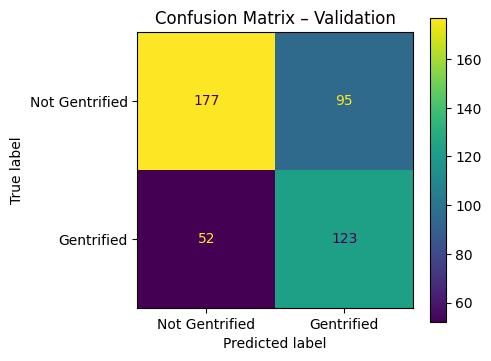


── Test ──
Accuracy: 0.6734
                    precision    recall  f1-score   support

Not Gentrified (0)       0.78      0.64      0.71       273
    Gentrified (1)       0.56      0.72      0.63       174

          accuracy                           0.67       447
         macro avg       0.67      0.68      0.67       447
      weighted avg       0.70      0.67      0.68       447



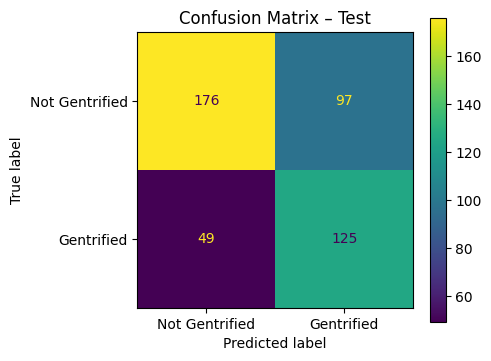

In [16]:

for split_name, X_sp, y_sp in [('Validation', X_val, y_val), ('Test', X_test, y_test)]:
    y_pred = model_weighted.predict(X_sp)
    acc = accuracy_score(y_sp, y_pred)
    print(f"\n── {split_name} ──")
    print(f"Accuracy: {acc:.4f}")
    print(classification_report(y_sp, y_pred, target_names=['Not Gentrified (0)', 'Gentrified (1)']))
    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay.from_predictions(
        y_sp, y_pred,
        display_labels=['Not Gentrified', 'Gentrified'],
        ax=ax
    )
    ax.set_title(f'Confusion Matrix – {split_name}')
    plt.tight_layout()
    plt.show()


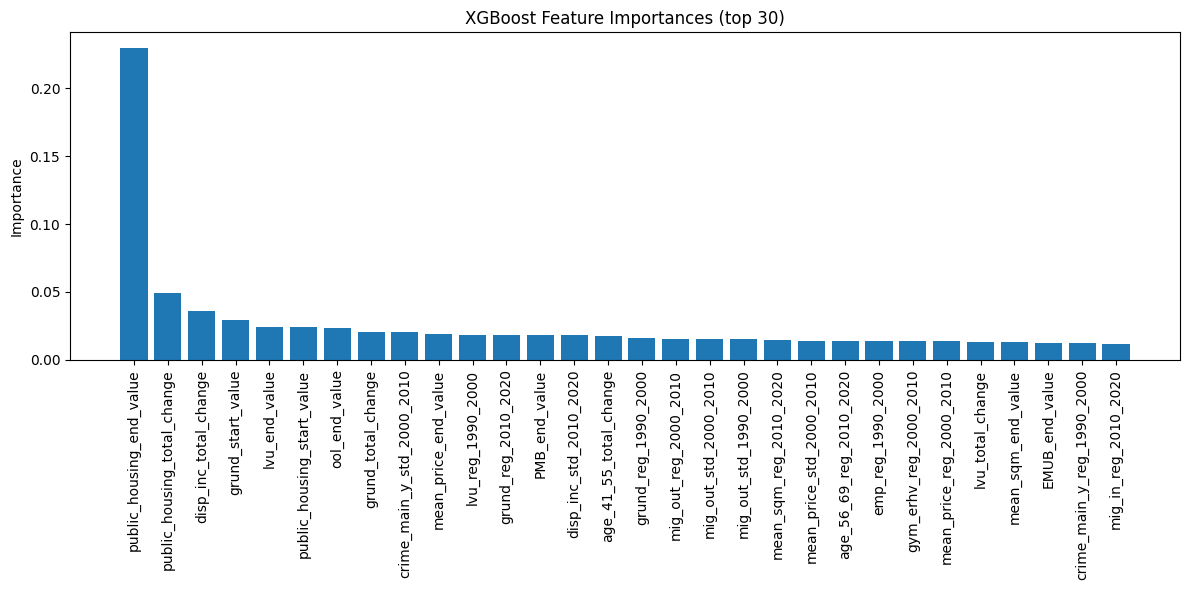

In [17]:
# Feature importance (top 30)
fi = model_weighted.feature_importances_
names = np.array(X.columns)
idx = np.argsort(fi)[::-1][:30]

plt.figure(figsize=(12, 6))
plt.bar(range(len(idx)), fi[idx], align='center')
plt.xticks(range(len(idx)), names[idx], rotation=90)
plt.ylabel('Importance')
plt.title('XGBoost Feature Importances (top 30)')
plt.tight_layout()
plt.show()


## 8. Binary Threshold Sweep

Grid-search a decision threshold $t$ on the validation set, optimising `f1_macro`.

$$\hat{y} = \begin{cases} 1 & \text{if } P(\text{Gentrified} \mid x) \geq t \\ 0 & \text{otherwise} \end{cases}$$


Best threshold: t=0.50
Val f1_macro at best t: 0.6663

Validation report at best threshold:
                    precision    recall  f1-score   support

Not Gentrified (0)       0.77      0.65      0.71       272
    Gentrified (1)       0.56      0.70      0.63       175

          accuracy                           0.67       447
         macro avg       0.67      0.68      0.67       447
      weighted avg       0.69      0.67      0.68       447



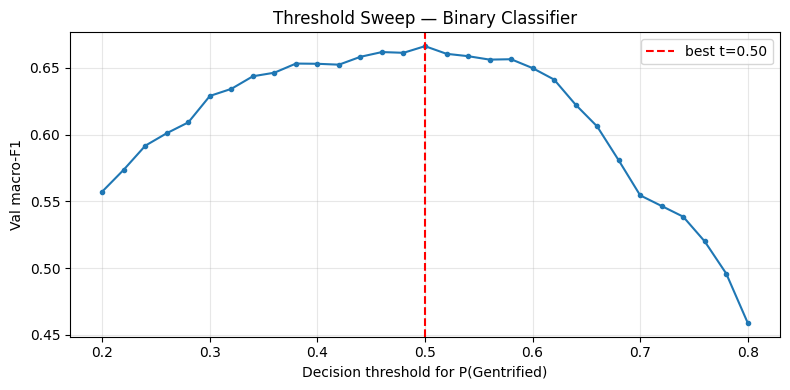

Saved: ../results/models\threshold_sweep.jpg

Using threshold t=0.500 for downstream predictions.


In [19]:

# ── 1-D threshold sweep for binary classifier ─────────────────────────────────
# Predict Gentrified (1) if P(Gentrified | x) >= t, else Not Gentrified (0).
# Grid-search threshold t on validation set to maximise f1_macro.

proba_val_all  = model_weighted.predict_proba(X_val)
proba_test_all = model_weighted.predict_proba(X_test)

classes_list = list(getattr(model_weighted, 'classes_', np.array([0, 1])))
idx_class0   = classes_list.index(0) if 0 in classes_list else 0
idx_class1   = classes_list.index(1) if 1 in classes_list else 1

thresholds = np.arange(0.20, 0.81, 0.02)
best_f1, best_t = -1.0, 0.5
f1_vals = []

for t in thresholds:
    p1 = proba_val_all[:, idx_class1]
    y_pred_t = np.where(p1 >= t,
                        classes_list[idx_class1],
                        classes_list[idx_class0]).astype(int)
    f1 = f1_score(y_val, y_pred_t, average='macro', zero_division=0)
    f1_vals.append(f1)
    if f1 > best_f1:
        best_f1, best_t = f1, float(t)

# Keep best_s1 as alias (for downstream compatibility)
best_s1 = best_t
best_s2 = 1.0  # unused in binary, kept for compatibility

print(f"Best threshold: t={best_t:.2f}")
print(f"Val f1_macro at best t: {best_f1:.4f}")

# Validation report at best threshold
p1_val = proba_val_all[:, idx_class1]
y_val_scaled = np.where(p1_val >= best_t,
                        classes_list[idx_class1],
                        classes_list[idx_class0]).astype(int)
print("\nValidation report at best threshold:")
print(classification_report(y_val, y_val_scaled,
                             target_names=['Not Gentrified (0)', 'Gentrified (1)']))

# Plot threshold sweep
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(thresholds, f1_vals, marker='o', ms=3)
ax.axvline(best_t, color='red', linestyle='--', label=f'best t={best_t:.2f}')
ax.set_xlabel('Decision threshold for P(Gentrified)')
ax.set_ylabel('Val macro-F1')
ax.set_title('Threshold Sweep — Binary Classifier')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()

plot_path = os.path.join(RESULTS_DIR, 'threshold_sweep.jpg')
fig.savefig(plot_path, format='jpeg', dpi=300)
plt.show()
print(f"Saved: {plot_path}")
print(f"\nUsing threshold t={best_t:.3f} for downstream predictions.")


Test evaluation at threshold=0.500:
                    precision    recall  f1-score   support

Not Gentrified (0)       0.78      0.64      0.71       273
    Gentrified (1)       0.56      0.72      0.63       174

          accuracy                           0.67       447
         macro avg       0.67      0.68      0.67       447
      weighted avg       0.70      0.67      0.68       447



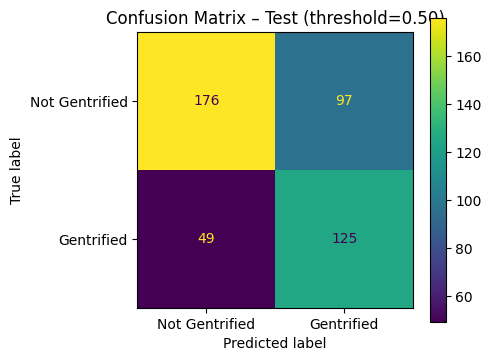

In [20]:

# Evaluation with best threshold on test set
p1_test = proba_test_all[:, idx_class1]
y_test_pred_tuned = np.where(p1_test >= best_t,
                              classes_list[idx_class1],
                              classes_list[idx_class0]).astype(int)

print(f"Test evaluation at threshold={best_t:.3f}:")
print(classification_report(y_test, y_test_pred_tuned,
                             target_names=['Not Gentrified (0)', 'Gentrified (1)']))
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_test_pred_tuned,
    display_labels=['Not Gentrified', 'Gentrified'], ax=ax
)
ax.set_title(f'Confusion Matrix – Test (threshold={best_t:.2f})')
plt.tight_layout()
plt.show()


## 9. Save 2020 Predictions (Full Dataset)

In [21]:

# Apply threshold to all clusters (not just test set)
proba_all = model_weighted.predict_proba(X)
p1_all    = proba_all[:, idx_class1]
pred_all  = np.where(p1_all >= best_t,
                     classes_list[idx_class1],
                     classes_list[idx_class0]).astype(int)

pred_df = pd.DataFrame({
    'cluster_id': data.loc[X.index, 'cluster_id'].values,
    'prediction': pred_all
})

out_path = os.path.join(RESULTS_DIR, 'predictions_cph.csv')
pred_df.to_csv(out_path, index=False)
print(f"Saved 2020 predictions: {out_path}  (rows={len(pred_df)})")
print(pred_df['prediction'].value_counts().sort_index())
print("  0 = Not Gentrified,  1 = Gentrified")


Saved 2020 predictions: ../results/models\predictions_cph.csv  (rows=2232)
prediction
0    1144
1    1088
Name: count, dtype: int64
  0 = Not Gentrified,  1 = Gentrified


In [22]:

# Save XGBoost probabilities for ensemble notebook
proba_out = pd.DataFrame({
    'cluster_id':       data.loc[X.index, 'cluster_id'].values,
    'p_not_gentrified': proba_all[:, idx_class0],
    'p_gentrified':     proba_all[:, idx_class1],
    'split':            ['all'] * len(X.index),  # full dataset; split info not tracked here
    'actual_class':     y.loc[X.index].values,
})

# Mark train / val / test splits so notebook 14 can evaluate on test only
split_labels = pd.Series('train', index=X.index)
split_labels.loc[X_test.index] = 'test'
split_labels.loc[X_val.index]  = 'val'
proba_out['split'] = split_labels.values

xgb_proba_path = os.path.join(RESULTS_DIR, 'xgb_proba_cph.csv')
proba_out.to_csv(xgb_proba_path, index=False)
print(f"Saved XGBoost probabilities: {xgb_proba_path}  (rows={len(proba_out)})")
print(proba_out['split'].value_counts().sort_index())
print(proba_out.head())


Saved XGBoost probabilities: ../results/models\xgb_proba_cph.csv  (rows=2232)
split
test      447
train    1338
val       447
Name: count, dtype: int64
  cluster_id  p_not_gentrified  p_gentrified  split  actual_class
0      101_1          0.446325      0.553675    val             1
1     101_10          0.340339      0.659661    val             1
2    101_100          0.952690      0.047310  train             0
3   101_1000          0.685979      0.314021   test             1
4   101_1001          0.829669      0.170331   test             0
